In [1]:
import numpy as np
import scipy
from Scripts.Optimization.optimization import Optimizer
from Scripts.Finite_Elements.Beam_FEA_System.beam_type import BeamType
from Scripts.Finite_Elements.Beam_FEA_System.beam_system import BeamSystem
from Scripts.Finite_Elements.material_properties import Materials


In [2]:
opt = Optimizer()
opt.independent_properties_calc()

opt.active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 0.6,
    "strut_diameter": 50.0,
    "strut_thickness": 0.6,
    "strut_distance": 425,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

res = opt.run_opt()

x = np.array(res.x)
x_expanded = list(opt.reform_dvs(x).values())

'''
opt.fixed_design_variables = {
    "arm_diameter": False,
    "arm_thickness": False,
    "strut_diameter": False,
    "strut_thickness": False,
    "strut_distance": False,
    "hub_radius": False,
    "hub_flange_thickness": False,
    "hub_web_thickness": False
}
'''

cons_res_opt, cons_labels_opt = opt.test_results(x)


dv_keys = list(opt.design_variables_initial_guess.keys())

print("===== Optimized =====")
print("design variables")
for i in range(len(dv_keys)):
    print(f"   {dv_keys[i]}: {x_expanded[i]}")

print("constraints")
for i in range(len(cons_res_opt)):
    print(f"   {cons_labels_opt[i]}: {cons_res_opt[i]}")

print(f"mass w/ payload: {res.fun * 1000} kg")


print("OPT_OUTPUT")
opt.test_results(x, detailed_output=True)

print("Initial guess opt actual:")
print(res.x)

Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.30233957405287726
   strut_diameter: 50.0
   strut_thickness: 0.3609053941590715
   strut_distance: 556.4454900912388
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.9999999999999993
   stress: 0.977859849282712
   displacement amplitude: 0.29064885956701497
   energy: 0.3260612162830091
   damage: 0.0
mass w/ payload: 0.8250115057269486 kg
OPT_OUTPUT
Initial guess opt actual:
[3.02339574e-01 3.60905394e-01 5.56445490e+02]


<llm-snippet-file>C:/Desktop/UAV_Mission/Optimization_Experiments.ipynb</llm-snippet-file>


<llm-snippet-file>C:/Desktop/UAV_Mission/Optimization_Experiments.ipynb</llm-snippet-file>


In [3]:
import os
import pandas as pd

table_path = "Tables/Sensitivity_Testing_Ver_2.csv"

for i in range(8):
    case_title = "Case " + str(i)
    x2 = [
        ((x[0] - 0.001 * x[0])) if i in (0, 1, 2, 3) else (x[0] + 0.001 * x[0]),
        ((x[1] - 0.001 * x[1])) if i in (0, 1, 4, 5) else (x[1] + 0.001 * x[1]),
        ((x[2] - 0.001 * x[2])) if i in (0, 3, 5, 7) else (x[2] + 0.001 * x[2])
    ]
    print(x2)
    cons_res_opt, cons_labels_opt = opt.test_results(x2)
    mass = opt.mass(opt.reform_dvs(x2))

    data = {}
    data.update(opt.reform_dvs(x2))
    opt_dictionary = dict(zip(cons_labels_opt, cons_res_opt))
    data.update(opt_dictionary)
    data.update({"mass": mass * 1000})

    print(data)

    # Ensure directory exists
    os.makedirs(os.path.dirname(table_path), exist_ok=True)

    new_col_df = pd.DataFrame.from_dict(data, orient="index", columns=[case_title])

    if os.path.exists(table_path):
        try:
            df_existing = pd.read_csv(table_path, index_col=0)
        except Exception:
            df_existing = pd.DataFrame()

        if df_existing.empty:
            df = new_col_df
        else:
            for idx in new_col_df.index:
                if idx not in df_existing.index:
                    df_existing.loc[idx] = pd.NA
            df_existing[case_title] = new_col_df[case_title]
            df = df_existing
    else:
        df = new_col_df

    df.to_csv(table_path, index=True)


[np.float64(0.30203723447882436), np.float64(0.36054448876491246), np.float64(555.8890446011475)]
{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.30203723447882436), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.36054448876491246), 'strut_distance': np.float64(555.8890446011475), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7, 'deflection': np.float64(1.0012389228226173), 'stress': np.float64(0.9787084766803353), 'displacement amplitude': np.float64(0.2898293469713321), 'energy': np.float64(0.326057775514179), 'damage': np.float64(0.0), 'mass': np.float64(0.8240767363681032)}
[np.float64(0.30203723447882436), np.float64(0.36054448876491246), np.float64(557.00193558133)]


C:\Users\natha\AppData\Local\Temp\ipykernel_32476\3909578900.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_existing.loc[idx] = pd.NA


{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.30203723447882436), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.36054448876491246), 'strut_distance': np.float64(557.00193558133), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7, 'deflection': np.float64(1.0006197634642706), 'stress': np.float64(0.9789799450296035), 'displacement amplitude': np.float64(0.29287129035720555), 'energy': np.float64(0.32605951879918127), 'damage': np.float64(0.0), 'mass': np.float64(0.8245433584355776)}
[np.float64(0.30203723447882436), np.float64(0.3612662995532306), np.float64(557.00193558133)]
{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.30203723447882436), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.3612662995532306), 'strut_distance': np.float64(557.00193558133), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7, 'deflection': np.float64(1.0000053967943991), 'stress': np.float64(0.978405163981718), 'displacement ampl

In [4]:
import os
import pandas as pd
table_path = "Tables/Sensitivity_Testing_Ver_2.csv"
case_title = "Optimal Point"

mass = opt.mass(opt.reform_dvs(x))

data = {}
data.update(opt.reform_dvs(x))
opt_dictionary = dict(zip(cons_labels_opt, cons_res_opt))
data.update(opt_dictionary)
data.update({"mass":mass * 1000})

print(data)

# Ensure directory exists
os.makedirs(os.path.dirname(table_path), exist_ok=True)

new_col_df = pd.DataFrame.from_dict(data, orient="index", columns=[case_title])

if os.path.exists(table_path):
    try:
        df_existing = pd.read_csv(table_path, index_col=0)
    except Exception:
        df_existing = pd.DataFrame()

    if df_existing.empty:
        df = new_col_df
    else:
        for idx in new_col_df.index:
            if idx not in df_existing.index:
                df_existing.loc[idx] = pd.NA
        df_existing[case_title] = new_col_df[case_title]
        df = df_existing
else:
    df = new_col_df

df.to_csv(table_path, index=True) 


{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.30233957405287726), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.3609053941590715), 'strut_distance': np.float64(556.4454900912388), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7, 'deflection': np.float64(0.9993822662342826), 'stress': np.float64(0.9767420681239066), 'displacement amplitude': np.float64(0.2884998768840999), 'energy': np.float64(0.32606291208285526), 'damage': np.float64(0.0), 'mass': np.float64(0.8250115057269486)}


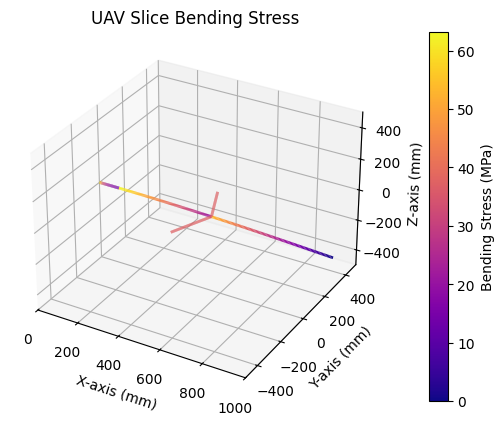

In [5]:
from Scripts.visualization import drone_geometry_stress

drone_geometry_stress(opt.fea, 1, 100)

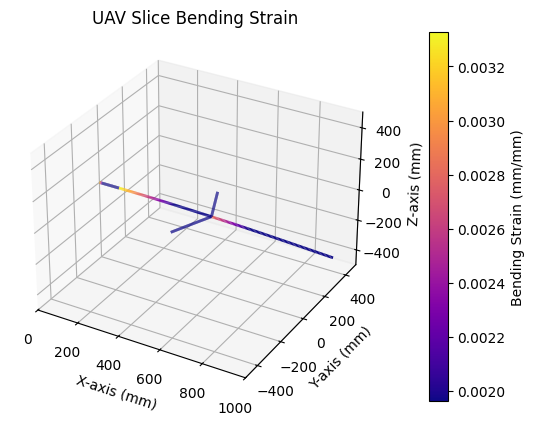

In [6]:
from Scripts.visualization import drone_geometry_strain

drone_geometry_strain(opt.fea, 1, 100)

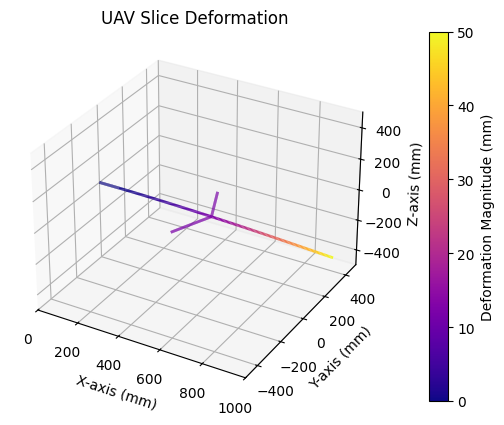

In [7]:
from Scripts.visualization import drone_geometry_deformation

drone_geometry_deformation(opt.fea, 1, 100)

In [8]:
import Scripts.unit_conversions as uc
opt.fea.beam_system.solve_natural_frequencies()
print(f"First Nf: {opt.fea.beam_system.natural_frequencies[0] * uc.rad_per_s_to_Hz} Hz")
print(f"Second Nf: {opt.fea.beam_system.natural_frequencies[1] * uc.rad_per_s_to_Hz} Hz")

First Nf: 24.244310331581133 Hz
Second Nf: 55.42029117679677 Hz


In [12]:
print(352.7148774623214 * uc.rad_per_s_to_Hz)

print(max(opt.fea.beam_system.mag_displacements_amplitude))

56.1363162501806
21.79866446752611


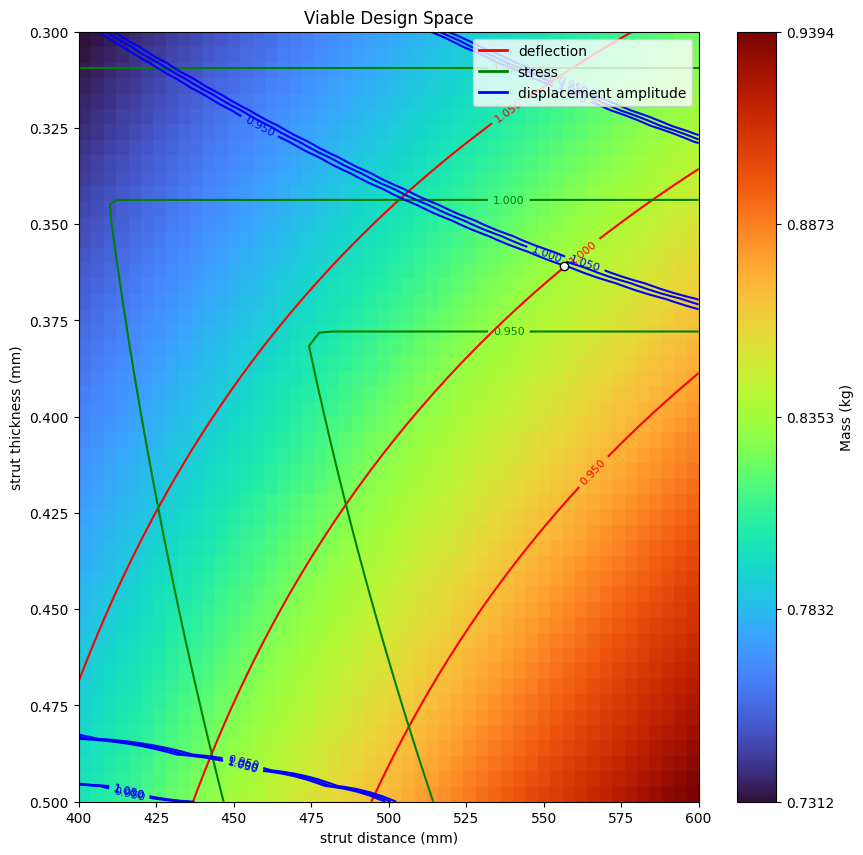

In [10]:
# plot the space
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "strut_distance", "strut_thickness", 50, design_variables, (400, 600), (0.3, 0.5), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

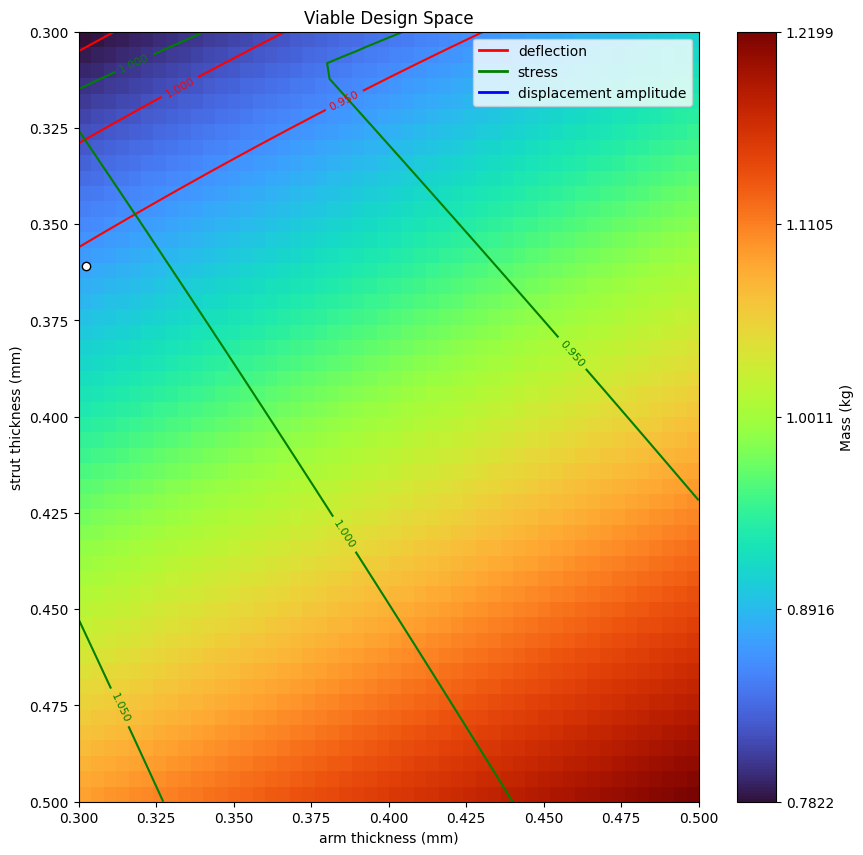

In [20]:
# plot the space
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "arm_thickness", "strut_thickness", 50, design_variables, (0.2, 0.5), (0.3, 0.5), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[1], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm thickness (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

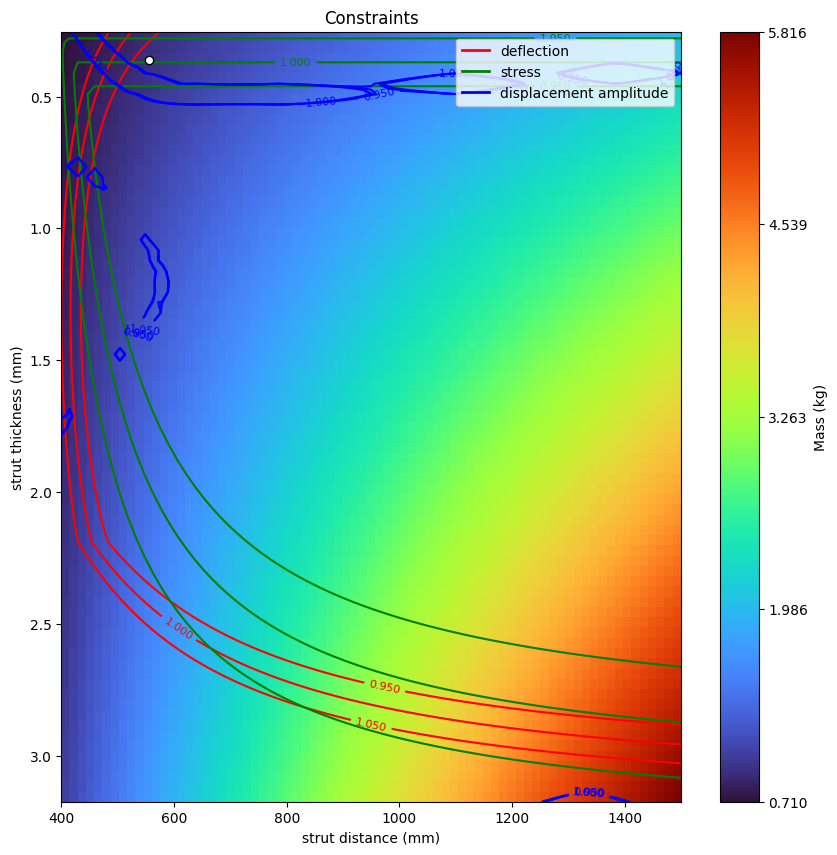

In [16]:
# zoomed out
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "strut_distance", "strut_thickness", 75, design_variables, None,None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

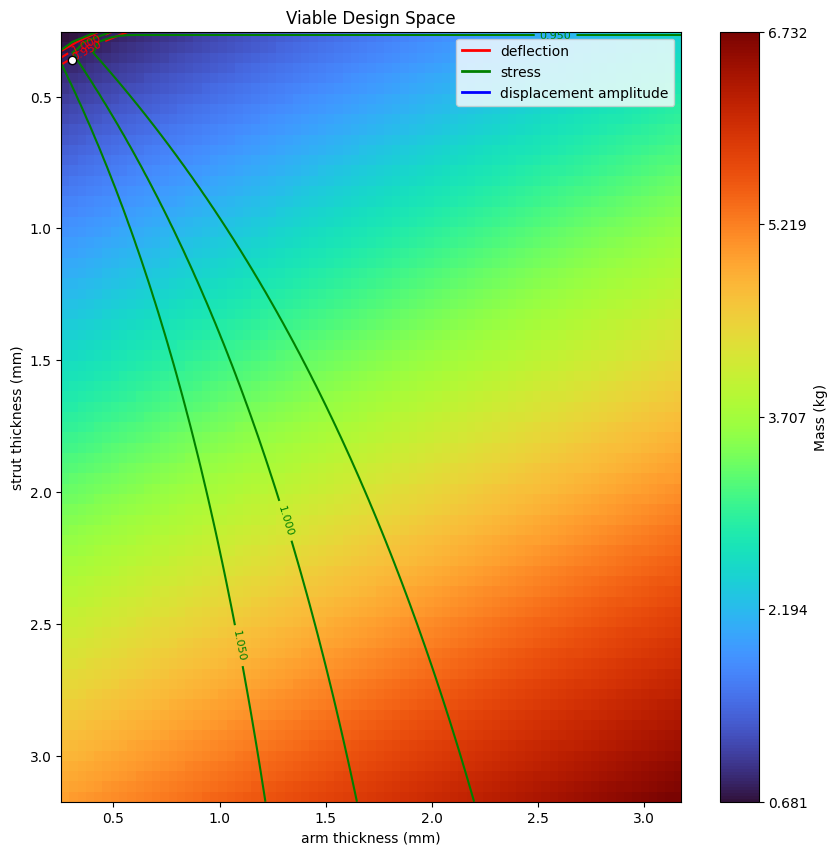

In [17]:
# plot the space
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "arm_thickness", "strut_thickness", 75, design_variables, None, None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[1], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm thickness (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

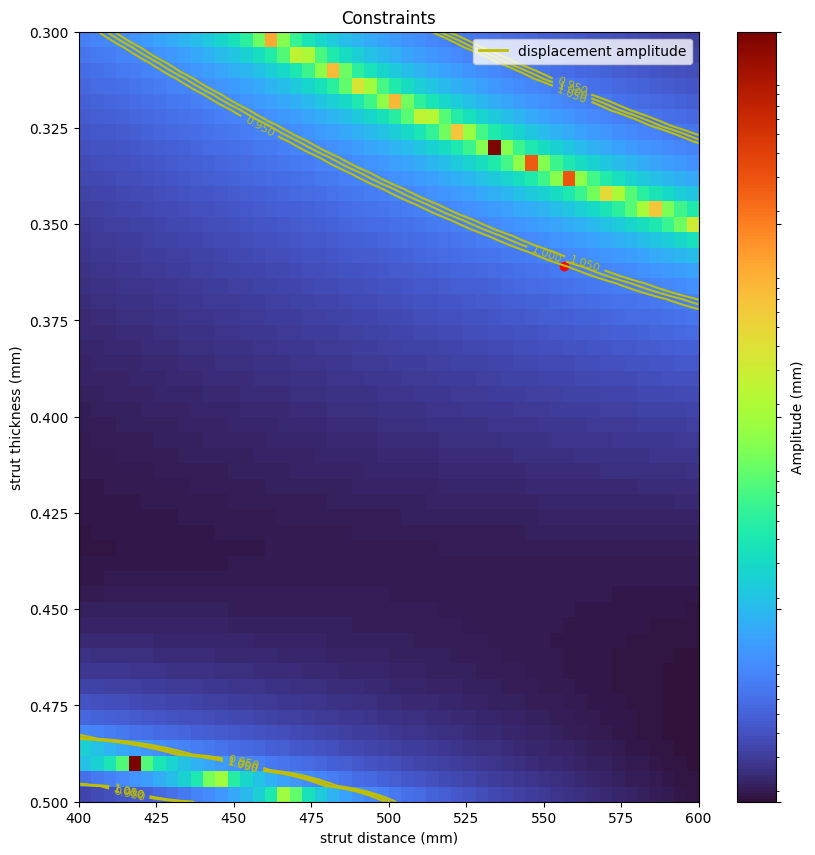

In [18]:
# plot the space
from Scripts.visualization import design_space_freq
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_freq(opt, "strut_distance", "strut_thickness", 50, design_variables,(400,600),(0.3,0.5),{
    "deflection": False,
    "stress": False,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
plt.scatter(x_expanded[4], x_expanded[3], c='r')
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

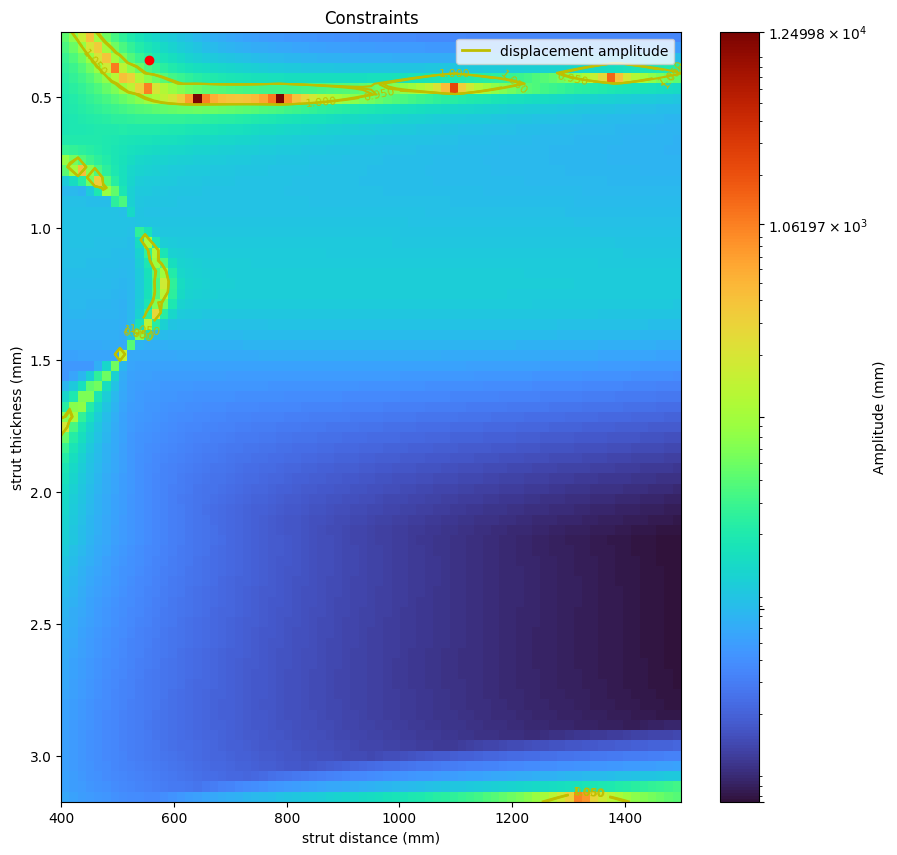

In [19]:

# zoomed out
from Scripts.visualization import design_space_freq
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_freq(opt, "strut_distance", "strut_thickness", 75, design_variables,None,None, {
    "deflection": False,
    "stress": False,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
plt.scatter(x_expanded[4], x_expanded[3], c='r')
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

Initial guess 1 tol=e-12

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 25,
    "strut_diameter": 50.0,
    "strut_thickness": 25,
    "strut_distance": 510,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.31612437848973063
   strut_diameter: 50.0
   strut_thickness: 0.3602027837054039
   strut_distance: 509.98696996881597
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.9999999999970214
   stress: 0.955560709497491
   frequency: 0.26171190065852373
   energy: 0.326065371252493
   damage: 0.0
mass w/ payload: 0.8265042304244963 kg
OPT_OUTPUT
Initial guess opt actual:
[3.16124378e-01 3.60202784e-01 5.09986970e+02]

Initial guess 2 tol=e-12

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 1,
    "strut_diameter": 50.0,
    "strut_thickness": 0.6,
    "strut_distance": 425,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}


===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.3022755041161241
   strut_diameter: 50.0
   strut_thickness: 0.3608985852993385
   strut_distance: 556.6928996805128
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.9999999999999539
   stress: 0.9780731466461088
   frequency: 0.2914667465901592
   energy: 0.3260612237046038
   damage: 0.0
mass w/ payload: 0.8250114520506969 kg
OPT_OUTPUT
Initial guess opt actual:
[3.02275504e-01 3.60898585e-01 5.56692900e+02]

Inital Guess 3 tol=1e-18

Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.30227574532156787
   strut_diameter: 50.0
   strut_thickness: 0.3608980022929013
   strut_distance: 556.6928997650245
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.999999999999994
   stress: 0.9780730549779
   frequency: 0.29146623894235507
   energy: 0.32606122370460633
   damage: 0.0
mass w/ payload: 0.8250114520506582 kg
OPT_OUTPUT
Initial guess opt actual:
[3.02275745e-01 3.60898002e-01 5.56692900e+02]

Initial Guess 4 tol=1e-18

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 0.3,
    "strut_diameter": 50.0,
    "strut_thickness": 0.6,
    "strut_distance": 425,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

Positive directional derivative for linesearch
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.31654251873360006
   strut_diameter: 50.0
   strut_thickness: 0.48657929350939877
   strut_distance: 412.17184660354866
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 1.0000000000000013
   stress: 1.0000000000000078
   frequency: 1.0000000000001152
   energy: 0.3261353943704316
   damage: 0.0
mass w/ payload: 0.8461615400019418 kg
OPT_OUTPUT
Initial guess opt actual:
[3.16542519e-01 4.86579294e-01 4.12171847e+02]

In [5]:
import Scripts.Finite_Elements.drone_fea as fea
import Scripts.unit_conversions as uc
uav_geo = opt.drone_geometry
uav_fea = fea.DroneFEA(uav_geo)
uav_fea.create_drone_nodes()
uav_fea.create_drone_beams()
# uav_fea.boundary_conditions()
uav_fea.solve_fea()
uav_fea.beam_system.solve_natural_frequencies()
np.set_printoptions(precision=3,suppress=True)
print(f"First Nf: {uav_fea.beam_system.natural_frequencies[0] * uc.rad_per_s_to_Hz} Hz")
print(f"Second Nf: {uav_fea.beam_system.natural_frequencies[1] * uc.rad_per_s_to_Hz} Hz")
print(f"Third Nf: {uav_fea.beam_system.natural_frequencies[2] * uc.rad_per_s_to_Hz} Hz")
print(f"Fourth Nf: {uav_fea.beam_system.natural_frequencies[3] * uc.rad_per_s_to_Hz} Hz")
print(f"Nf: {uav_fea.beam_system.natural_frequencies * uc.rad_per_s_to_Hz} Hz")

First Nf: 0.0 Hz
Second Nf: 0.0 Hz
Third Nf: 0.0 Hz
Fourth Nf: 6.389410714062791e-05 Hz
Nf: [    0.        0.        0.        0.        0.        0.001    24.537
    24.537    26.497    32.29     32.29     33.88     35.235    35.773
    35.773    36.611    36.611    37.341    37.341    40.103    40.103
    43.937    49.969    49.969    58.522    63.304    63.304    72.453
    72.453    72.557    77.067    77.067    79.09     81.195    87.79
    87.79     90.486    90.486    94.143    94.143    97.484    97.484
   110.675   138.136   138.136   138.494   138.494   139.388   139.539
   139.539   139.775   139.775   141.886   180.201   182.152   182.152
   182.286   182.286   182.576   185.507   185.573   185.573   185.736
   185.736   186.013   186.013   187.006   192.544   192.544   210.613
   231.835   238.617   238.617   244.249   244.249   251.978   251.978
   253.347   286.829   295.484   295.484   329.032   329.032   343.259
   674.533   704.792   704.792   763.312   763.312   778.

In [ ]:
# Try blade num
# try different material
#
